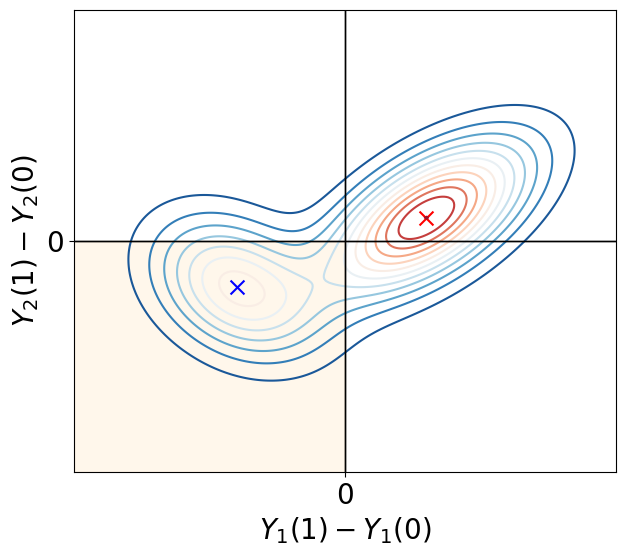

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define two Gaussian modes: one positive, one negative
mean1 = np.array([1.5, 0.5])   # positive average effect
cov1 = np.array([[1.5, 0.8],
                 [0.8, 1.2]])

mean2 = np.array([-2.0, -1.0])  # negative mode
cov2 = np.array([[1.0, -0.3],
                 [-0.3, 1.0]])

# Mixture weights
w1, w2 = 0.65, 0.35
assert np.isclose(w1 + w2, 1.0), "Mixture weights must sum to 1."

# Grid for contour plot
x = np.linspace(-5, 5, 250)
y = np.linspace(-5, 5, 250)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Two-component Gaussian mixture
rv1 = multivariate_normal(mean1, cov1)
rv2 = multivariate_normal(mean2, cov2)
Z = w1 * rv1.pdf(pos) + w2 * rv2.pdf(pos)  # weighted mixture

# Mixture mean (weighted average of component means)
mix_mean = w1 * mean1 + w2 * mean2

# Ensure positive average effect on the first dimension
assert mix_mean[0] > 0, f"Mixture mean on dim 1 is not positive: {mix_mean[0]:.3f}"

# Plot contours with larger fonts
plt.figure(figsize=(7,6))
contours = plt.contour(X, Y, Z, levels=12, cmap="RdBu_r")
#plt.clabel(contours, inline=True, fontsize=14)  # larger contour labels

# Shade ONLY the bottom-left quadrant (light transparent orange)
plt.axhspan(-5, 0, xmin=0, xmax=0.5, color="orange", alpha=0.08)

# Axes and markers with larger font
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

# Updated labels
plt.xlabel(r"$Y_1(1) - Y_1(0)$", fontsize=20)
plt.ylabel(r"$Y_2(1) - Y_2(0)$", fontsize=20)  # I assume you meant (1) not (0) twice

# Mode markers
plt.scatter(*mean1, color="red", marker="x", s=100, label="Positive Mode")
plt.scatter(*mean2, color="blue", marker="x", s=100, label="Negative Mode")

# Mixture mean marker
#plt.scatter(*mix_mean, color="green", s=120, marker="*", label=f"Mixture Mean ({mix_mean[0]:.2f}, {mix_mean[1]:.2f})")

#plt.legend(fontsize=14)
plt.xticks([0],fontsize=20)
plt.yticks([0],fontsize=20)
plt.savefig("jointdist.pdf", bbox_inches = "tight")
plt.show()

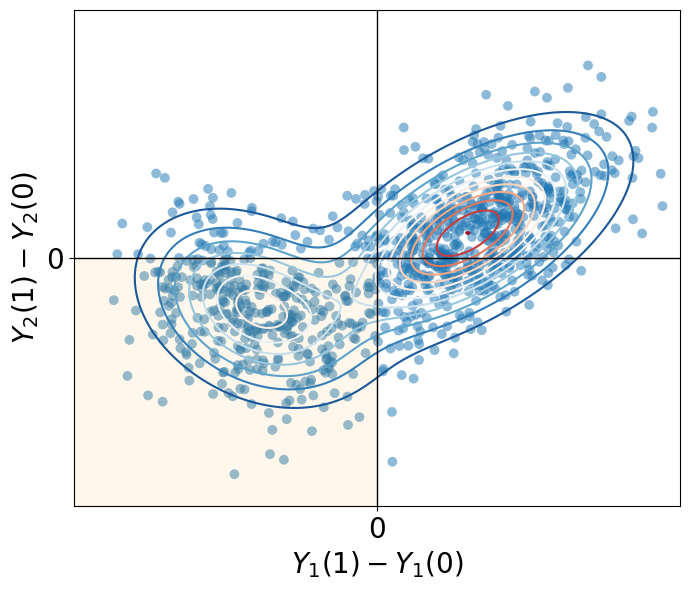

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(2)

# Define two Gaussian modes
mean1 = np.array([1.5, 0.5])
cov1  = np.array([[1.5, 0.8],
                  [0.8, 1.2]])

mean2 = np.array([-2.0, -1.0])
cov2  = np.array([[1.0, -0.3],
                  [-0.3, 1.0]])

w1, w2 = 0.65, 0.35
n = 1000

# Sample from mixture
n1 = int(w1 * n)
n2 = n - n1
samples1 = np.random.multivariate_normal(mean1, cov1, n1)
samples2 = np.random.multivariate_normal(mean2, cov2, n2)
samples = np.vstack([samples1, samples2])

# Mixture mean
mix_mean = w1 * mean1 + w2 * mean2
assert mix_mean[0] > 0

# Plot
plt.figure(figsize=(7,6))

# Grid for contour plot
x = np.linspace(-5, 5, 250)
y = np.linspace(-5, 5, 250)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Two-component Gaussian mixture
rv1 = multivariate_normal(mean1, cov1)
rv2 = multivariate_normal(mean2, cov2)
Z = w1 * rv1.pdf(pos) + w2 * rv2.pdf(pos)  # weighted mixture

# Mixture mean (weighted average of component means)
mix_mean = w1 * mean1 + w2 * mean2

# Ensure positive average effect on the first dimension
assert mix_mean[0] > 0, f"Mixture mean on dim 1 is not positive: {mix_mean[0]:.3f}"

# Plot contours with larger fonts
contours = plt.contour(X, Y, Z, levels=12, cmap="RdBu_r")

# Scatter cloud
plt.scatter(samples[:,0], samples[:,1],
            s=50, alpha=0.5, edgecolors="none")

# Shade bottom-left quadrant
plt.axvspan(-5, 0, ymin=0, ymax=0.5, color="orange", alpha=0.08)

# Axes
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel(r"$Y_1(1) - Y_1(0)$", fontsize=20)
plt.ylabel(r"$Y_2(1) - Y_2(0)$", fontsize=20)

plt.xticks([0], fontsize=20)
plt.yticks([0], fontsize=20)

plt.xlim(-5,5)
plt.ylim(-5,5)

plt.tight_layout()
plt.savefig("jointdist_scatter.pdf", bbox_inches="tight")
plt.show()